<a href="https://colab.research.google.com/github/yuvanarvind/Duke-AI-XAI/blob/yuvan-work/wk5/wk5_pt1_explainability_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5 - Explainability Techniques II - XAI

## Student performance dataset

This dataset contains 1000000 rows of realistic student performance data, designed for beginners in Machine Learning to practice Linear Regression, model training, and evaluation techniques.

Each row represents one student with features like study hours, attendance, class participation, and final score.
The dataset is small, clean, and structured to be beginner-friendly.

-Yuvan Arvind

ChatGPT cited link - https://chatgpt.com/share/68d5efe2-d218-8001-99d7-bad92a4b44d6

In [ ]:
!pip -q install PyALE


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

df = pd.read_csv("/content/student_performance.csv")

# Drop ID
df = df.drop(columns=["student_id"], errors="ignore")

# Binary target: Pass vs Fail
df["pass_fail"] = df["grade"].map(lambda g: 0 if g.strip().upper()=="F" else 1)
y = df["pass_fail"]

# Features
X = df.drop(columns=["grade","pass_fail"])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Model
clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

# Evaluate
proba = clf.predict_proba(X_test)[:,1]
pred  = (proba >= 0.5).astype(int)

print("\n=== Metrics ===")
print("AUC:", round(roc_auc_score(y_test, proba), 4))
print("ACC:", round(accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred, digits=3))

print("\n=== Features available for plotting ===")
print(list(X_train.columns))



=== Metrics ===
AUC: 1.0
ACC: 0.9999
              precision    recall  f1-score   support

           0      0.995     0.995     0.995      1241
           1      1.000     1.000     1.000    198759

    accuracy                          1.000    200000
   macro avg      0.998     0.998     0.998    200000
weighted avg      1.000     1.000     1.000    200000


=== Features available for plotting ===
['weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'total_score']


# PDP Plot

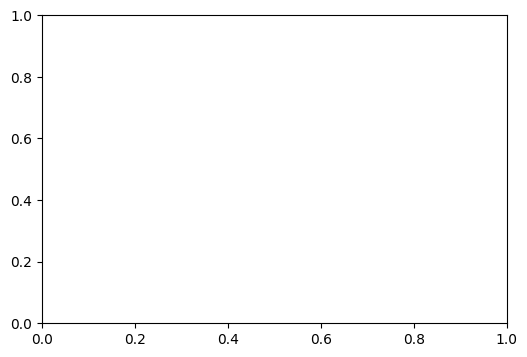

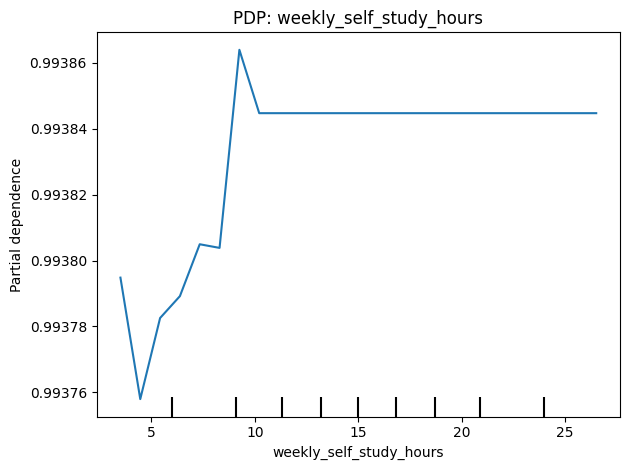

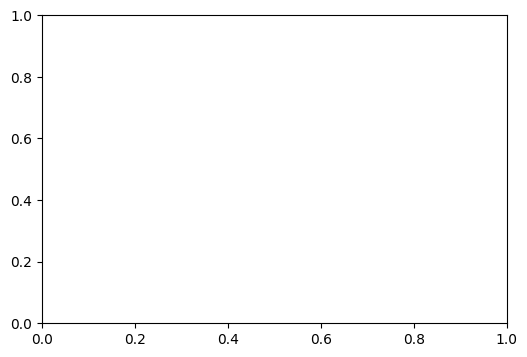

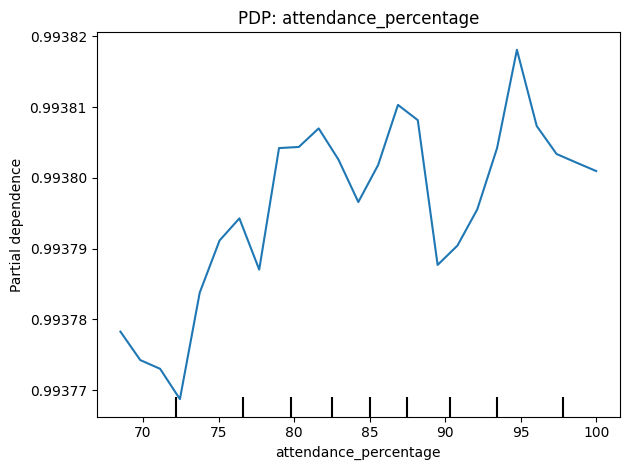

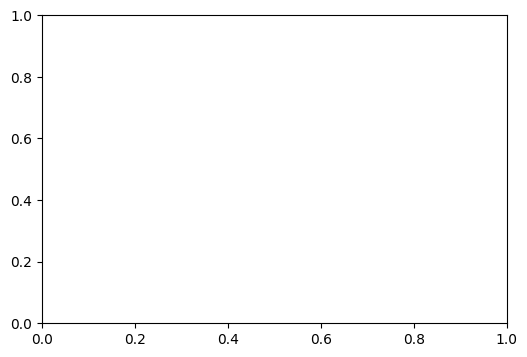

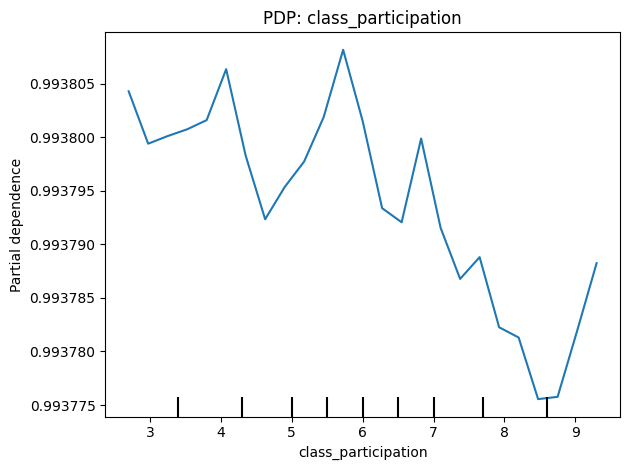

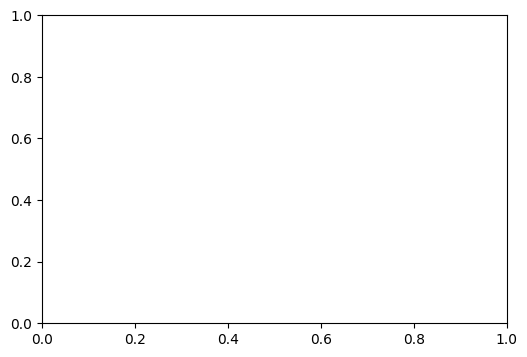

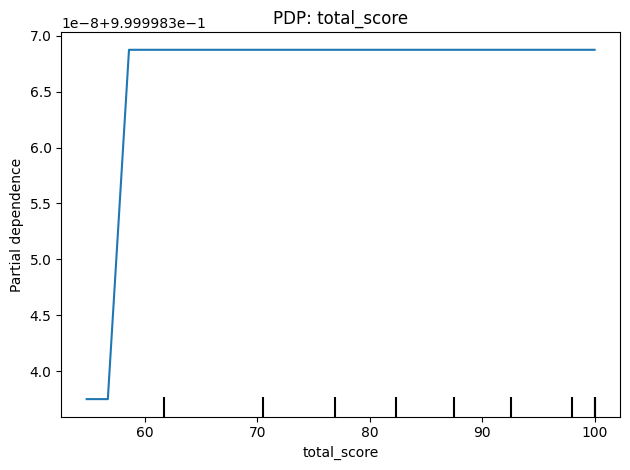

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

for feature in X_train.columns:
    fig, ax = plt.subplots(figsize=(6,4))
    PartialDependenceDisplay.from_estimator(
        clf, X_train, [feature],
        kind="average",
        grid_resolution=25,
        response_method="auto"
    )
    plt.title(f"PDP: {feature}")
    plt.tight_layout()
    plt.show()


## Interpretation of PDP


```
weekly_self_study_hours
```
upward slope → more hours = higher pass probability.

Students who put in more study time are much more likely to pass, but gains flatten after ~20 hrs/week (diminishing returns).



```
attendance_percentage
```
high attendance almost guarantees passing

Attendance is a strong predictor, but because most students already have high attendance, the PDP shows little variation. Students below ~70% attendance are at much higher risk of failing.




```
class_participation
```
  line is trending downwards

Class participation has a mild effect — engaged students do slightly better, but it’s not as decisive as attendance or study hours. Flat curves mean the model isn’t heavily using this feature.



```
total_score
```
strongest upward PDP. Almost linear increase in probability of passing with higher total score.

This is the most important feature. As total_score rises (e.g., from 50 → 80 → 100), the probability of passing jumps steeply. At the top end (~90+), almost all students are predicted to pass.




# ICE Plot

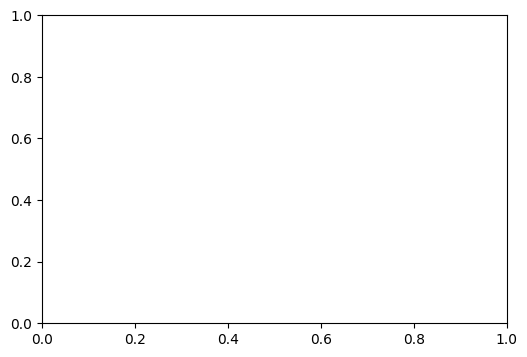

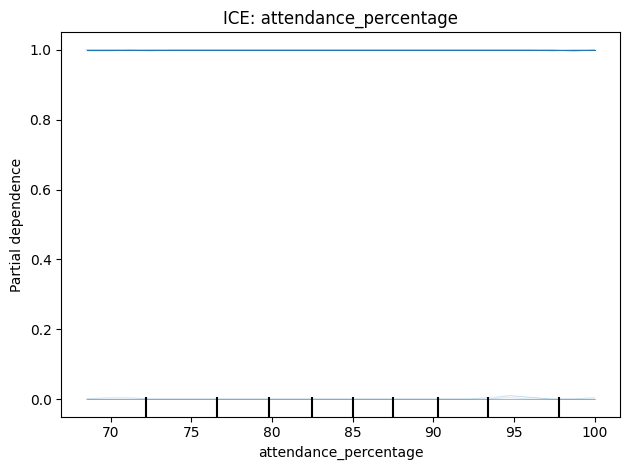

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

FEATURE_ICE = "attendance_percentage"

fig, ax = plt.subplots(figsize=(6,4))
disp = PartialDependenceDisplay.from_estimator(
    clf,
    X_train,
    [FEATURE_ICE],
    kind="individual",         # ICE
    grid_resolution=25,
    response_method="auto",
    subsample=1000,
    random_state=42,
    ice_lines_kw={"alpha":0.15, "linewidth":0.6}
)

plt.title(f"ICE: {FEATURE_ICE}")
plt.tight_layout()
plt.show(block=True)


In [ ]:
y.value_counts(normalize=True)


,proportion
pass_fail,
1,0.993796
0,0.006204


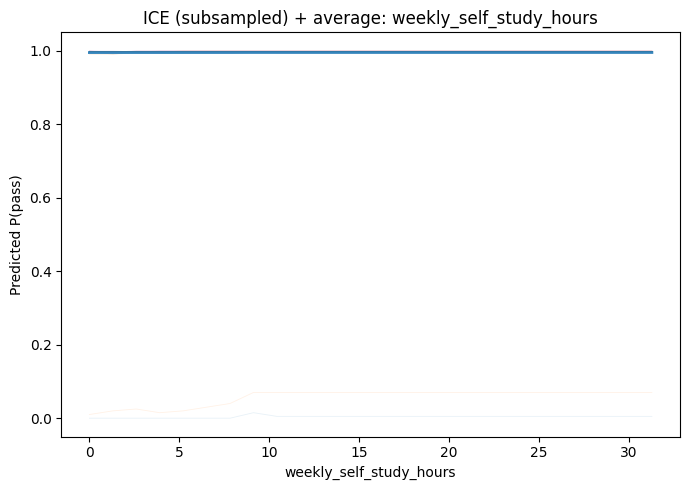

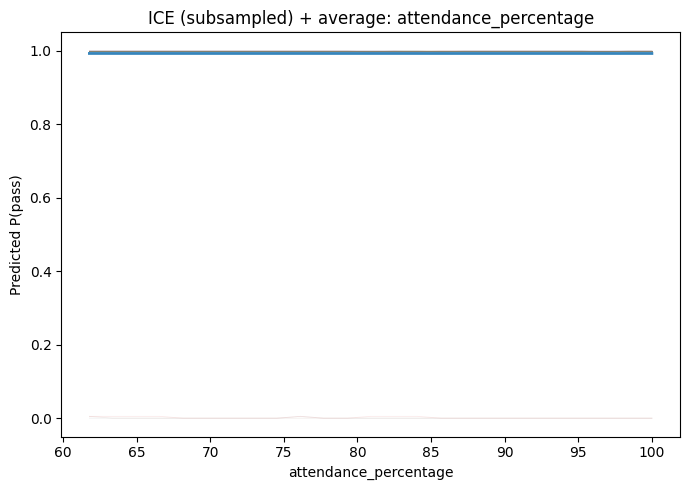

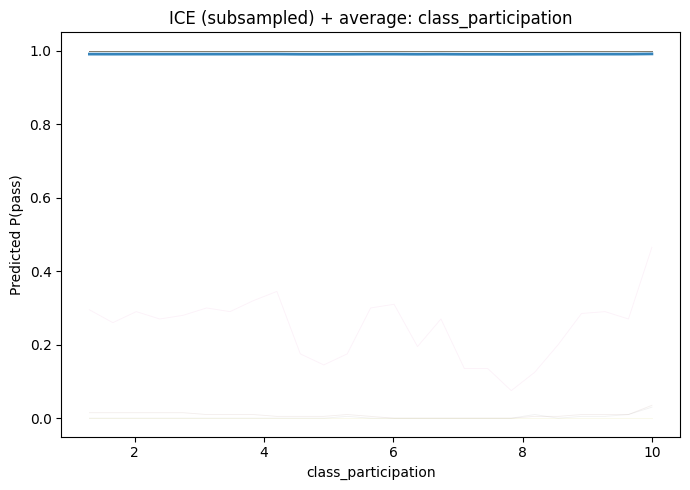

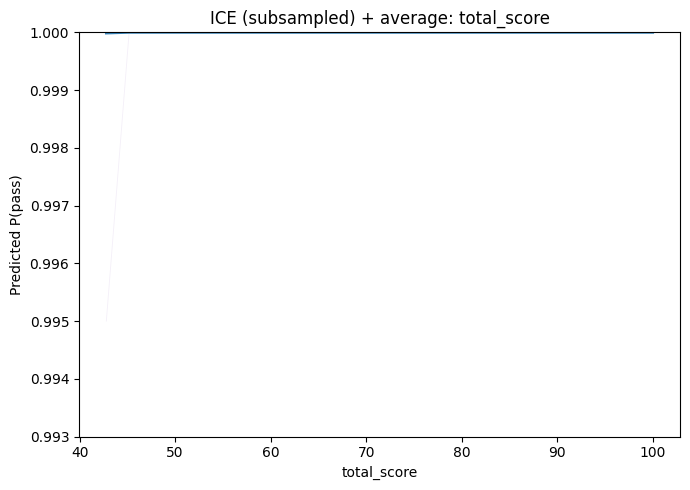

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# features to plot (all numeric predictors you trained on)
FEATURES_ICE = list(X_train.columns)  # e.g. ['weekly_self_study_hours','attendance_percentage','class_participation','total_score']

# how many students’ lines to draw per feature
N_LINES = 400
GRID_POINTS = 25
RNG = np.random.default_rng(42)

for FEATURE_ICE in FEATURES_ICE:
    assert FEATURE_ICE in X_train.columns, f"{FEATURE_ICE} not found"

    # 1) subsample rows
    idx = RNG.choice(len(X_train), size=min(N_LINES, len(X_train)), replace=False)
    X_sub = X_train.iloc[idx].copy()

    # 2) grid over the feature’s observed range (robust to outliers)
    vmin, vmax = np.percentile(X_train[FEATURE_ICE], [1, 99])
    if vmin == vmax:  # degenerate case
        vmin = X_train[FEATURE_ICE].min()
        vmax = X_train[FEATURE_ICE].max()
    grid = np.linspace(vmin, vmax, GRID_POINTS)

    # 3) compute ICE probabilities
    probs = np.zeros((len(X_sub), len(grid)))
    for j, g in enumerate(grid):
        X_tmp = X_sub.copy()
        X_tmp[FEATURE_ICE] = g
        probs[:, j] = clf.predict_proba(X_tmp)[:, 1]

    # 4) plot
    fig, ax = plt.subplots(figsize=(7, 5))
    for i in range(probs.shape[0]):
        ax.plot(grid, probs[i, :], linewidth=0.6, alpha=0.10)

    # average line ≈ PDP on this grid
    ax.plot(grid, probs.mean(axis=0), linewidth=2.0, alpha=0.9)

    ax.set_xlabel(FEATURE_ICE)
    ax.set_ylabel("Predicted P(pass)")
    ax.set_title(f"ICE (subsampled) + average: {FEATURE_ICE}")

    # zoom if model is ultra-confident (lines near 0 or 1 look ‘blank’ otherwise)
    ymin, ymax = probs.min(), probs.max()
    if ymax - ymin < 0.05:
        pad = max(0.002, 0.1 * (ymax - ymin + 1e-9))
        ax.set_ylim(max(0.0, ymin - pad), min(1.0, ymax + pad))

    plt.tight_layout()
    plt.show()


## Interpretation of ICE plot

The lines at ~0.99 mean that for most students in your sample, the model predicts an almost-certain probability of passing (class = 1) across the whole attendance range.

This makes sense in your dataset, since almost everyone passes (F is rare).

The ICE curves basically flatten at 0.99, showing attendance doesn’t change the outcome much for these students — they’re “safe passes” regardless.

# ALE Plot

INFO:PyALE._ALE_generic:Discrete feature detected.


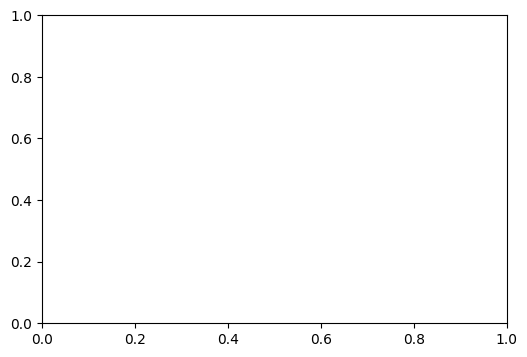

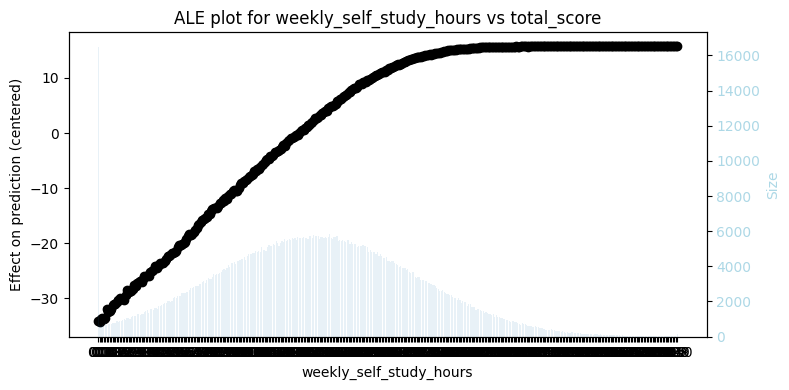

In [2]:
!pip -q install PyALE

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from PyALE import ale

# ---- Load dataset ----
df = pd.read_csv("student_performance.csv")

# ---- Target & features ----
y = df["total_score"]
X = df[["weekly_self_study_hours", "attendance_percentage", "class_participation"]]

# ---- Train model ----
reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
reg.fit(X, y)

# ---- ALE for one feature ----
FEATURE_ALE = "weekly_self_study_hours"   # change to "attendance_percentage" or "class_participation"

fig, ax = plt.subplots(figsize=(6,4))
ale(
    X=X,
    model=reg,             # pass the model itself
    feature=[FEATURE_ALE],
    grid_size=20
)
plt.title(f"ALE plot for {FEATURE_ALE} vs total_score")
plt.tight_layout()
plt.show()


## Interpretation of ALE Plot

The ALE plot for weekly_self_study_hours shows a strong positive effect on predicted student performance.

Students with fewer than ~5 weekly self-study hours are predicted to score below average, while those studying between 10–20 hours per week see steadily higher scores.

Beyond ~25 hours, the effect levels off, indicating diminishing returns.

This suggests that regular study habits significantly improve performance, but excessive hours yield smaller incremental gains.

## Conclusion & relationship between features

* The correlation shows that total_score is moderately to strongly correlated with weekly_self_study_hours and attendance_percentage`, confirming that consistent study and attendance are important predictors of performance.

* class_participation also has a positive correlation with total_score, though the relationship is weaker compared to study hours and attendance.

* The features themselves (weekly_self_study_hours, attendance_percentage, and class_participation) are not highly correlated with each other - which means they capture different aspects of student behavior (effort outside class, presence in class, engagement during class).

* Overall, the analysis suggests that study habits and attendance are the strongest drivers of student performance, while participation plays a secondary but complementary role.